# Titanic Dataset: Exploratory Data Analysis
This notebook will explore the Titanic dataset using Python. First, we import libraries for data manipulation and visualization.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

## Load Titanic Data
We load the Titanic dataset from the Excel file and save it as a CSV for easier handling.

In [6]:
from google.colab import files

uploaded = files.upload()

Saving titanic_data.csv to titanic_data.csv


In [8]:
data = pd.read_csv('titanic_data.csv')
data.to_csv('titanic.csv', index=False)
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Explore the Data
Let's check the structure of the dataset, see summary statistics, and identify any missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


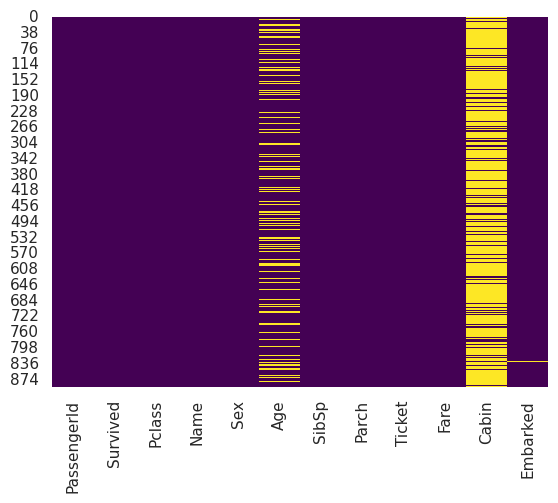

In [9]:
data.info()

data.describe()

data.isnull().sum()

sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.show()

## Clean the Data
We fill missing values for Age and Embarked and remove the Cabin column because it has too many missing values.

In [10]:
data['Age'].fillna(data['Age'].median(), inplace=True)

data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

data.drop('Cabin', axis=1, inplace=True)

data.isnull().sum()

/tmp/ipykernel_158/2631355262.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
/tmp/ipykernel_158/2631355262.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Overall Survival
We calculate the overall survival rate to understand what fraction of passengers survived the disaster.

In [11]:
overall_survival = data['Survived'].mean() * 100
print(f"Overall survival rate: {overall_survival:.2f}%")

Overall survival rate: 38.38%


## Survival by Sex
Now we explore how survival differed between men and women using a bar chart.

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


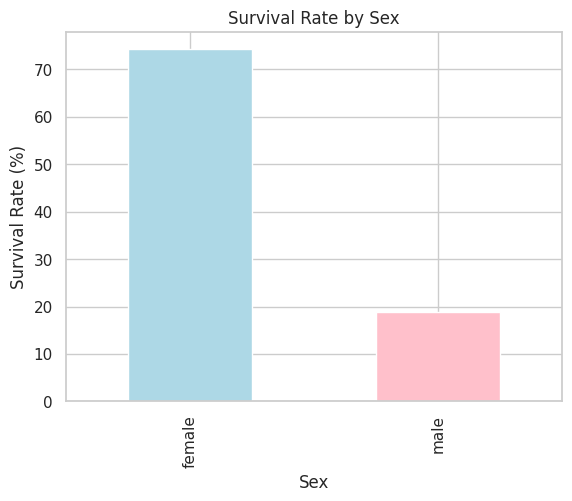

In [12]:
survival_sex = data.groupby('Sex')['Survived'].mean() * 100
print(survival_sex)

survival_sex.plot(kind='bar', color=['lightblue','pink'], title='Survival Rate by Sex')
plt.ylabel('Survival Rate (%)')
plt.show()

## Survival by Passenger Class
We analyze survival based on passenger class to see if wealth and cabin location affected chances of survival.

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


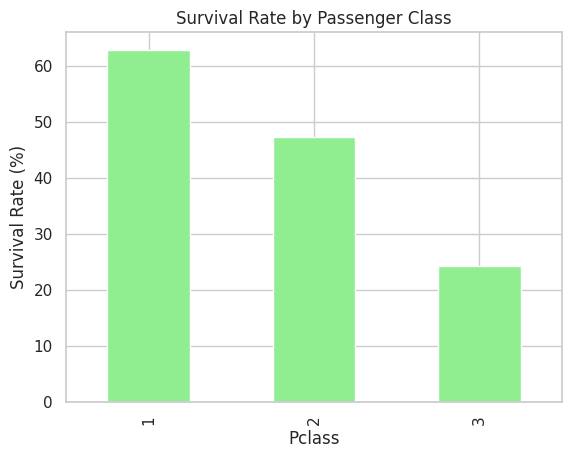

In [13]:
survival_class = data.groupby('Pclass')['Survived'].mean() * 100
print(survival_class)

survival_class.plot(kind='bar', color='lightgreen', title='Survival Rate by Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.show()

## Age Analysis
Here we look at the age distribution of survivors and non-survivors to see how age impacted survival chances.

Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64


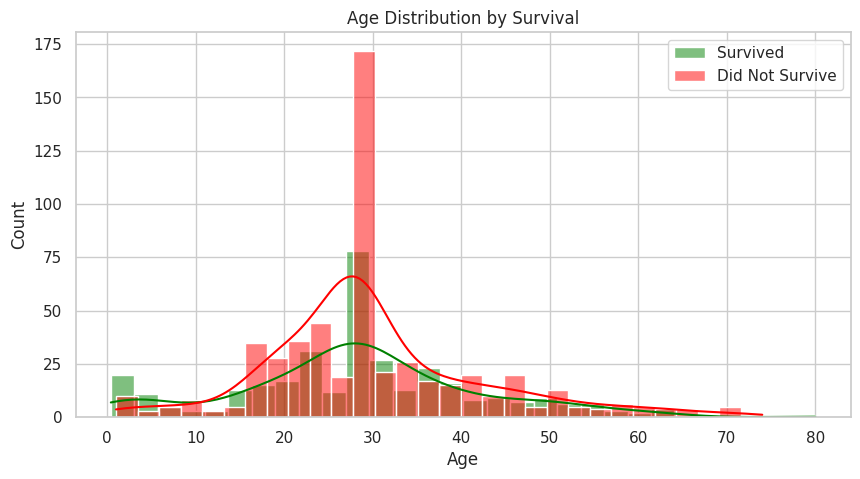

In [15]:
avg_age = data.groupby('Survived')['Age'].mean()
print(avg_age)

plt.figure(figsize=(10,5))
sns.histplot(data[data['Survived']==1]['Age'], color='green', label='Survived', kde=True, bins=30)
sns.histplot(data[data['Survived']==0]['Age'], color='red', label='Did Not Survive', kde=True, bins=30)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

## Feature Correlations
We check correlations between numerical features to see which factors may have influenced survival.

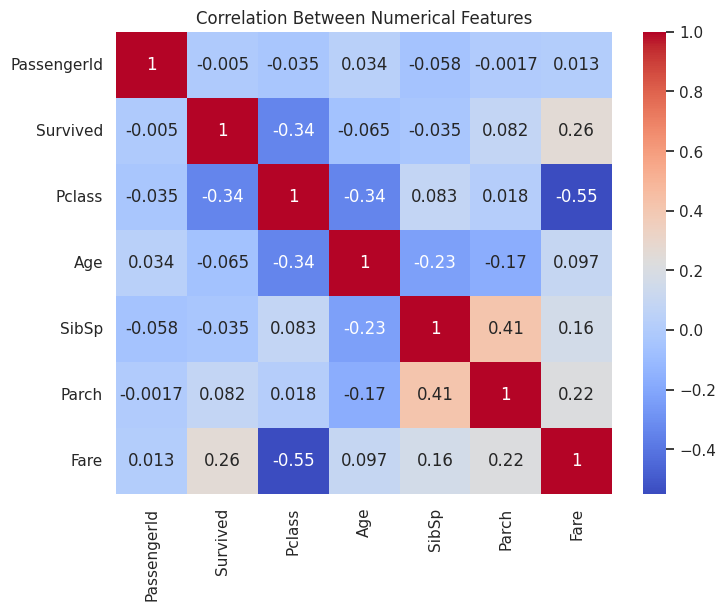

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Numerical Features')
plt.show()

## Survival by Sex and Class
We combine sex and passenger class to see which groups had the highest and lowest survival rates.

Survived               0          1
Sex    Pclass                      
female 1        3.191489  96.808511
       2        7.894737  92.105263
       3       50.000000  50.000000
male   1       63.114754  36.885246
       2       84.259259  15.740741
       3       86.455331  13.544669


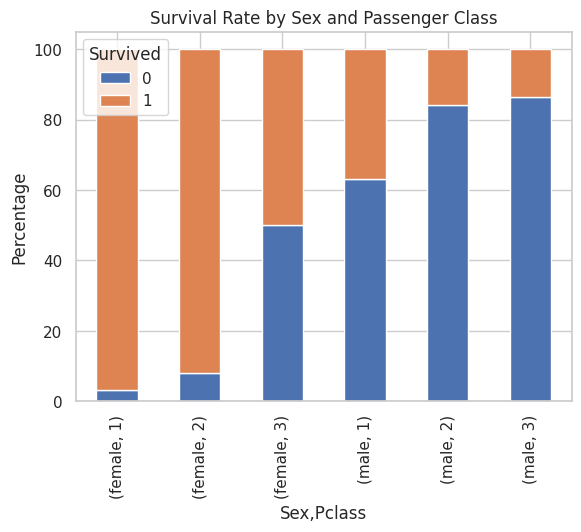

In [17]:
cross_tab = pd.crosstab([data['Sex'], data['Pclass']], data['Survived'], normalize='index') * 100
print(cross_tab)

cross_tab.plot(kind='bar', stacked=True)
plt.title('Survival Rate by Sex and Passenger Class')
plt.ylabel('Percentage')
plt.show()

## Save Cleaned Dataset
Finally, we save the cleaned dataset for future analysis or modeling.

In [18]:
data.to_csv('titanic_cleaned.csv', index=False)
print("Cleaned dataset saved as titanic_cleaned.csv")

Cleaned dataset saved as titanic_cleaned.csv
